**Entropy**

Is the measure of randomness or unpredictability in the dataset

*Formulae*

$$H_i = -\sum_{\substack{k=1 \\ p_{i,k} \neq 0}}^n p_{i,k} \log_2(p_{i,k})$$


**Information Gain**

- Represents how much entropy was removed during splitting at a node

*Formulae* :
$IG(T, A) = Entropy(T) - \sum_{v \in A} \frac{|T_v|}{|T|} \cdot Entropy(T_v)$


**IG(T,A)** -Information Gain of feature A on dataset T

**Entropy(T)** :Entropy at node before split (Parent Node)

 $\sum_{v \in A} \frac{|T_v|}{|T|}$ : Sum over all values v of feature A

**Entropy(Tv)** :Entropy after split(Child node)

**T**  : Total number of instances before split

**Tv** : Number of instances after split  

**Gini Impurity** : Calcculates the purity of the split at nodes of the decision tree

*formulae*  :   $$G_i = 1 - \sum_{k=1}^n P_{i,k}^2$$




In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('Datasets\Drug.csv')
df.head()

<>:6: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:6: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
C:\Users\HP\AppData\Local\Temp\ipykernel_14484\1769421112.py:6: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  df = pd.read_csv('Datasets\Drug.csv')


,Age,Sex,BP,Cholesterol,Na,K,Drug
0,23,F,HIGH,HIGH,0.792535,0.031258,drugY
1,47,M,LOW,HIGH,0.739309,0.056468,drugC
2,47,M,LOW,HIGH,0.697269,0.068944,drugC
3,28,F,NORMAL,HIGH,0.563682,0.072289,drugX
4,61,F,LOW,HIGH,0.559294,0.030998,drugY


In [2]:
df.duplicated()
df['BP'].unique()

<StringArray>
['HIGH', 'LOW', 'NORMAL']
Length: 3, dtype: str

In [3]:
df.isnull().sum()

Age            0
Sex            0
BP             0
Cholesterol    0
Na             0
K              0
Drug           0
dtype: int64

In [4]:
df.isna().sum()

Age            0
Sex            0
BP             0
Cholesterol    0
Na             0
K              0
Drug           0
dtype: int64

In [5]:
df[df.duplicated()]

,Age,Sex,BP,Cholesterol,Na,K,Drug


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    str    
 2   BP           200 non-null    str    
 3   Cholesterol  200 non-null    str    
 4   Na           200 non-null    float64
 5   K            200 non-null    float64
 6   Drug         200 non-null    str    
dtypes: float64(2), int64(1), str(4)
memory usage: 11.1 KB


Sex
M    104
F     96
Name: count, dtype: int64


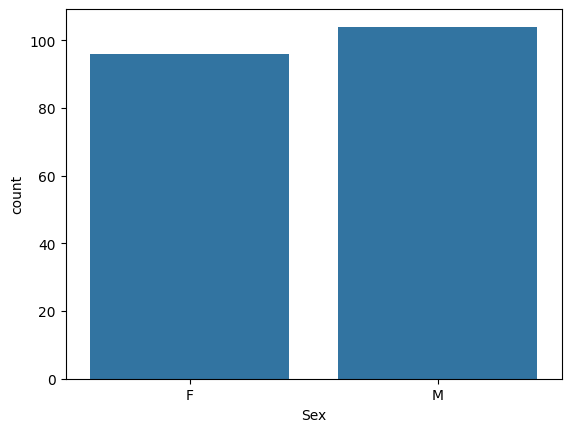

In [7]:
x = df.Sex.value_counts()
print(x)
p = sns.countplot(data=df, x= 'Sex')
plt.show()

Drug
drugY    91
drugX    54
drugA    23
drugC    16
drugB    16
Name: count, dtype: int64


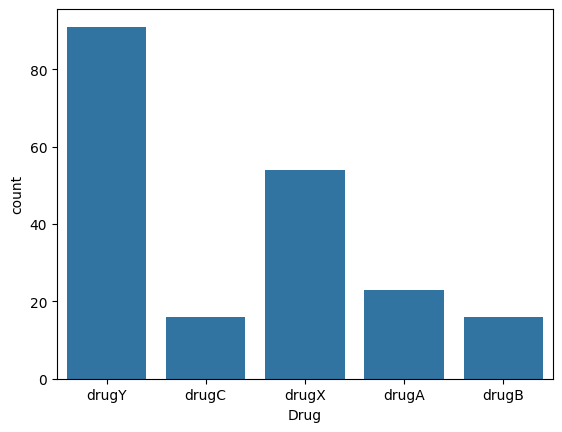

In [8]:
x= df.Drug.value_counts()
print(x)
p =sns.countplot(data=df, x= 'Drug')
plt.show()

In [9]:
df['Drug'].unique()

<StringArray>
['drugY', 'drugC', 'drugX', 'drugA', 'drugB']
Length: 5, dtype: str

C:\Users\HP\AppData\Local\Temp\ipykernel_14484\982774513.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['Drug'] == 'drugY']['Age'],color = 'green')
C:\Users\HP\AppData\Local\Temp\ipykernel_14484\982774513.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['Drug'] == 'drugC']['A

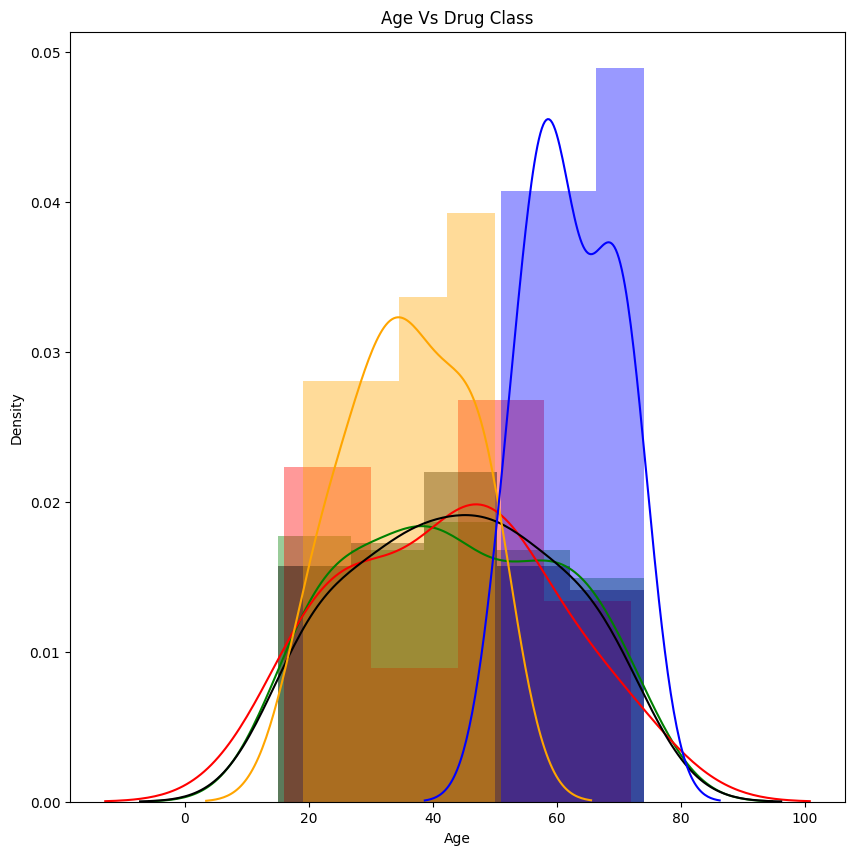

In [10]:
plt.figure(figsize=(10,10))
sns.distplot(df[df['Drug'] == 'drugY']['Age'],color = 'green')
sns.distplot(df[df['Drug'] == 'drugC']['Age'],color = 'red')
sns.distplot(df[df['Drug'] == 'drugX']['Age'],color = 'black')
sns.distplot(df[df['Drug'] == 'drugA']['Age'],color = 'orange')
sns.distplot(df[df['Drug'] == 'drugB']['Age'],color = 'blue')
plt.title('Age Vs Drug Class')
plt.show()

In [11]:
from sklearn.preprocessing import OrdinalEncoder
oe = OrdinalEncoder()
df['BP'] = oe.fit_transform(df[['BP']])
df['Sex'] = oe.fit_transform(df[['Sex']])
df['Cholesterol'] = oe.fit_transform(df[['Cholesterol']])
df['Drug'] = oe.fit_transform(df[['Drug']])

In [12]:
# df.drop('bp',axis=1,inplace=True)
df

,Age,Sex,BP,Cholesterol,Na,K,Drug
0,23,0.0,0.0,0.0,0.792535,0.031258,4.0
1,47,1.0,1.0,0.0,0.739309,0.056468,2.0
2,47,1.0,1.0,0.0,0.697269,0.068944,2.0
3,28,0.0,2.0,0.0,0.563682,0.072289,3.0
4,61,0.0,1.0,0.0,0.559294,0.030998,4.0
...,...,...,...,...,...,...,...
195,56,0.0,1.0,0.0,0.848774,0.073380,2.0
196,16,1.0,1.0,0.0,0.743021,0.061886,2.0
197,52,1.0,2.0,0.0,0.549945,0.055581,3.0
198,23,1.0,2.0,1.0,0.784520,0.055959,3.0


In [13]:
x = df.iloc[:,0:-1]
y= df.iloc[:,-1]
x
y

0      4.0
1      2.0
2      2.0
3      3.0
4      4.0
      ... 
195    2.0
196    2.0
197    3.0
198    3.0
199    3.0
Name: Drug, Length: 200, dtype: float64

In [14]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)  

In [15]:
X_train

,Age,Sex,BP,Cholesterol,Na,K
79,32,0.0,1.0,1.0,0.724422,0.066829
197,52,1.0,2.0,0.0,0.549945,0.055581
38,39,0.0,2.0,1.0,0.517515,0.053301
24,33,0.0,1.0,0.0,0.858387,0.025634
122,34,1.0,2.0,0.0,0.602557,0.026833
...,...,...,...,...,...,...
106,22,1.0,2.0,0.0,0.536324,0.044871
14,50,0.0,2.0,0.0,0.827780,0.065166
92,29,0.0,0.0,0.0,0.857934,0.029132
179,67,0.0,2.0,0.0,0.785251,0.049416


In [16]:
y_train

79     3.0
197    3.0
38     3.0
24     4.0
122    4.0
      ... 
106    3.0
14     3.0
92     4.0
179    4.0
102    2.0
Name: Drug, Length: 160, dtype: float64

In [17]:
from sklearn.tree import DecisionTreeClassifier
clf_gini = DecisionTreeClassifier(criterion='gini',random_state=0)
clf_gini.fit(X_train,y_train)
y_pred_gini =clf_gini.predict(X_test)

In [18]:
y_pred_gini

array([3., 0., 3., 2., 4., 4., 4., 3., 0., 3., 0., 3., 4., 4., 1., 4., 1.,
       3., 2., 4., 1., 3., 3., 4., 4., 4., 2., 3., 4., 4., 4., 2., 4., 4.,
       0., 4., 3., 0., 4., 0.])

In [19]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(accuracy_score(y_pred_gini,y_test))

0.9


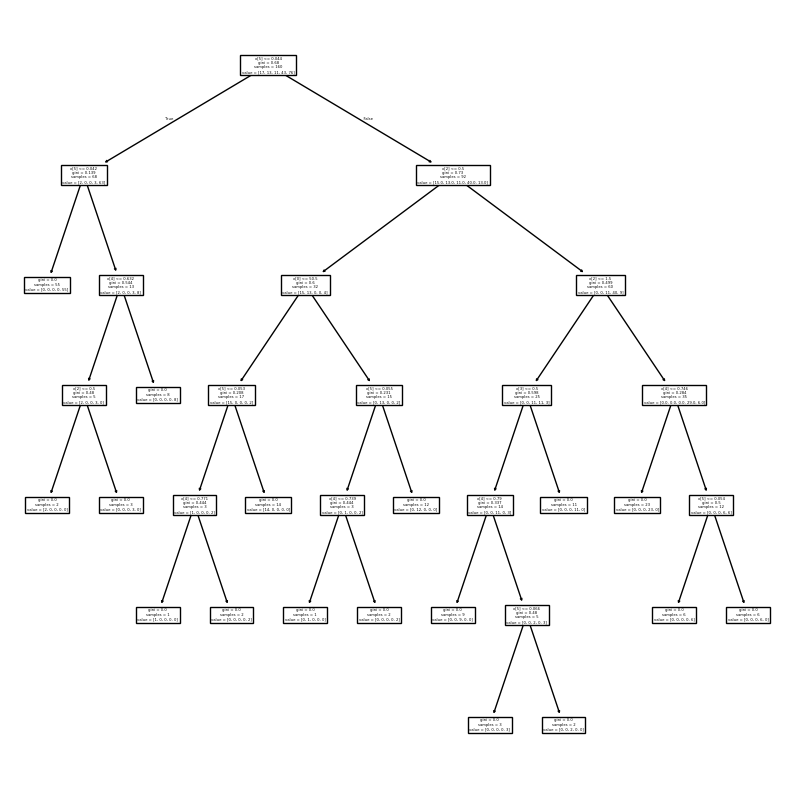

In [20]:
from sklearn import tree
plt.figure(figsize=(10,10))
tree.plot_tree(clf_gini)
plt.show()

In [21]:
clf_entropy = DecisionTreeClassifier(criterion ='entropy',max_depth = 3,random_state=0)
clf_entropy.fit(X_train,y_train)
y_pred_entropy = clf_entropy.predict(X_test)

0.775


[Text(0.4230769230769231, 0.875, 'x[5] <= 0.055\nentropy = 1.923\nsamples = 160\nvalue = [17, 13, 11, 43, 76]'),
 Text(0.15384615384615385, 0.625, 'x[5] <= 0.042\nentropy = 0.988\nsamples = 94\nvalue = [4, 1, 1, 13, 75]'),
 Text(0.28846153846153844, 0.75, 'True  '),
 Text(0.07692307692307693, 0.375, 'entropy = 0.0\nsamples = 55\nvalue = [0, 0, 0, 0, 55]'),
 Text(0.23076923076923078, 0.375, 'x[4] <= 0.657\nentropy = 1.63\nsamples = 39\nvalue = [4, 1, 1, 13, 20]'),
 Text(0.15384615384615385, 0.125, 'entropy = 1.159\nsamples = 15\nvalue = [4, 0, 1, 10, 0]'),
 Text(0.3076923076923077, 0.125, 'entropy = 0.785\nsamples = 24\nvalue = [0, 1, 0, 3, 20]'),
 Text(0.6923076923076923, 0.625, 'x[2] <= 0.5\nentropy = 1.93\nsamples = 66\nvalue = [13, 12, 10, 30, 1]'),
 Text(0.5576923076923077, 0.75, '  False'),
 Text(0.5384615384615384, 0.375, 'x[0] <= 50.5\nentropy = 0.999\nsamples = 25\nvalue = [13, 12, 0, 0, 0]'),
 Text(0.46153846153846156, 0.125, 'entropy = 0.0\nsamples = 13\nvalue = [13, 0, 0, 0,

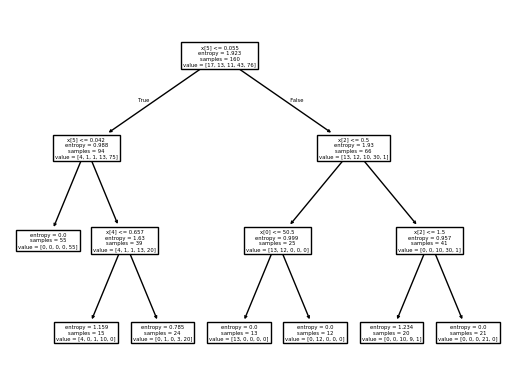

In [22]:
print(accuracy_score(y_test,y_pred_entropy))
plt.Figure(figsize=(10,10))
tree.plot_tree(clf_entropy)

In [23]:
clf_ginii = DecisionTreeClassifier(criterion = 'gini',max_depth = 3,random_state=0)
clg_ginii.fit(X_train,y_train)
y_pred_g =clf_ginii.predict(X_test)
print(accuracy_score(y_test,y_pred_g))
plt.figure(figsize =(10,10))
tree.plot_tree(clf_entropy.fit(X_train,y_train)) 
plt.show()

NameError: name 'clg_ginii' is not defined